# Bivariate analysis of categorical variables and the chi-square test

This notebook presents a bivariate analysis of categorical variables, specifically examining the relationship between individuals' countrys of origin, birth years and genders. A chi-square test is employed to determine if there is a statistically significant association between these factors over time. 

The aim is to understand how the geographical distribution of the population has changed over time and whether there is a significant over-representation of female astronomers/physicists in certain countrys.


In [22]:
import pandas as pd

import scipy.stats as stats
import statsmodels.api as sm

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import numpy as np
import seaborn as sns

In [23]:
import pprint
import csv
import sys

import time
import datetime
from dateutil import parser
from shutil import copyfile


In [24]:
import warnings
warnings.filterwarnings('ignore')


## Create a dataframe with the data to be analysed

We use in this notebook the data produced in the da2 chapter, i.e. a list of persons with birth year, gender, place of birth, world country of birth

In [25]:
csv_address='../da3_data/da3-birthYear-gender-region-country.csv'
df_p = pd.read_csv(csv_address)
df_p.head()

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE
0,http://www.wikidata.org/entity/Q204508,NaN,1782,male,Sighișoara,POINT (24.791111 46.216945),http://www.wikidata.org/entity/Q193001,1781-1790,8,Eastern Europe,RO,România,Romania,ROU
1,http://www.wikidata.org/entity/Q4525913,NaN,1790,male,Makhnivka,POINT (28.676944 49.721944),http://www.wikidata.org/entity/Q2511152,1781-1790,8,Eastern Europe,UA,Україна,Ukraine,UKR
2,http://www.wikidata.org/entity/Q1063531,NaN,1786,male,London,POINT (-0.1275 51.507222),http://www.wikidata.org/entity/Q84,1781-1790,24,Northern Europe,UK,United Kingdom,United Kingdom,GBR
3,http://www.wikidata.org/entity/Q4514643,NaN,1789,male,Voronezh,POINT (39.210556 51.671667),http://www.wikidata.org/entity/Q3426,1781-1790,9,European Russia,RU,Россия,Russian Federation,RUS
4,http://www.wikidata.org/entity/Q15729291,NaN,1783,male,Santarcangelo di Romagna,POINT (12.44657 44.06326),http://www.wikidata.org/entity/Q111954,1781-1790,19,Southern Europe,IT,Italia,Italy,ITA


In [26]:
### Inspect the dataframe and 
# notably if there are missing values
df_p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11362 entries, 0 to 11361
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   uriPer      11362 non-null  object
 1   labelPer    367 non-null    object
 2   birthYear   11362 non-null  int64 
 3   gender      11362 non-null  object
 4   labelPlace  11362 non-null  object
 5   geometry    11362 non-null  object
 6   uriPlace    11362 non-null  object
 7   periods     11362 non-null  object
 8   FID         11362 non-null  int64 
 9   REGION      11362 non-null  object
 10  CNTR_ID     11361 non-null  object
 11  CNTR_NAME   11362 non-null  object
 12  NAME_ENGL   11362 non-null  object
 13  ISO3_CODE   11362 non-null  object
dtypes: int64(2), object(12)
memory usage: 1.2+ MB


### Verify variables: gender

In [27]:
### Group and count
# We observe some dispersion that requires grouping the categories of the variable
df_gender = df_p.groupby('gender').size()
df_gender = pd.DataFrame(df_gender.sort_values(ascending = False))
df_gender.columns=['number']
print(df_gender)

        number
gender        
male      9348
female    2014


## Distribution of countries of birth

In [28]:
### Group and count
# We observe some dispersion that requires grouping the categories of the variable
df_country = df_p.groupby('NAME_ENGL').size()
df_country = pd.DataFrame(df_country.sort_values(ascending = False))
df_country.columns=['number']
print(df_country.iloc[:50])
#print(df_country[(df_country.number < 21) & (df_country.number >5)])



                        number
NAME_ENGL                     
Germany                   1629
France                    1213
Italy                      999
Czechia                    786
United Kingdom             639
United States              599
Spain                      593
Russian Federation         520
Poland                     410
Ukraine                    339
Austria                    267
Hungary                    264
Romania                    235
Japan                      195
Switzerland                172
Greece                     168
Denmark                    124
Slovakia                   122
Belarus                    122
Netherlands                120
Sweden                     119
Belgium                    104
Slovenia                    87
Bulgaria                    81
Israel                      75
Croatia                     74
China                       70
Lithuania                   65
Argentina                   56
Norway                      54
Georgia 

In [29]:
### Example of values
print(len(df_p[df_p.NAME_ENGL=='Chile']))
df_p[df_p.NAME_ENGL=='Chile'].head(3)

15


,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE
1886,http://www.wikidata.org/entity/Q4822242,NaN,1858,male,Dalcahue,POINT (-73.6473 -42.3796),http://www.wikidata.org/entity/Q13031,1851-1860,15,South America,CL,Chile,Chile,CHL
2366,http://www.wikidata.org/entity/Q5711604,NaN,1864,male,Santiago,POINT (-70.65 -33.4375),http://www.wikidata.org/entity/Q2887,1861-1870,15,South America,CL,Chile,Chile,CHL
2803,http://www.wikidata.org/entity/Q28057680,NaN,1877,male,Chillán,POINT (-72.1033 -36.6067),http://www.wikidata.org/entity/Q3774,1871-1880,15,South America,CL,Chile,Chile,CHL


In [30]:
### We define a function that codes and aggregates the values in order to avoid dispersion, 
# which would make them difficult to analyse.

def codeCountry(country: str):
    if 'Russian Federation' in country \
        or 'Kazakhstan' in country \
        or 'Georgia' in country \
        or 'Uzbekistan' in country \
        or 'Armenia' in country \
        or 'Azerbaijan' in country:
        output='Russian Federation'
    elif 'Estonia' in country \
        or 'Latvia' in country \
        or 'Finland' in country \
        or 'Belarus' in country \
        or 'Lithuania' in country:
        output='Baltic States Fin. Belar.'
    elif 'Moldova' in country \
        or 'Serbia' in country \
        or 'Slovenia' in country \
        or 'Slovakia' in country \
        or 'Romania' in country \
        or 'Croatia' in country \
        or 'Bulgaria' in country:
        output='Central Europe'
    elif 'Norway' in country \
        or 'Denmark' in country \
        or 'Sweden' in country:
        output='Scandinavia'
    elif 'Argentina' in country \
        or 'Brazil' in country \
        or 'Chile' in country:
        output='South America'    
    elif 'Spain' in country \
        or 'Portugal' in country:
        output='Spain Port.'    
    elif 'Belgium' in country \
        or 'Netherlands' in country:
        output='Belgium Netherl.'   
    elif 'Australia' in country \
        or 'New Zealand' in country:
        output='Australia New Z.'      
    elif 'Canada' in country \
        or 'United States' in country:
        output='United States Can.'   
    elif 'Austria' in country \
        or 'Hungary' in country:
        output='Austria Hungary'       
    else:
        output=country
    return output                   

In [31]:
### Test the function
r='Belgium'
#r='Latvia'
codeCountry(r)

'Belgium Netherl.'

In [32]:
### Create a new column with the coded values
df_p['coded_country']=df_p.NAME_ENGL.apply(lambda x : codeCountry(x))

In [33]:
### Example
df_p.iloc[31:35]

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE,coded_country
31,http://www.wikidata.org/entity/Q10767938,NaN,1785,male,Břidličná,POINT (17.371126 49.911676),http://www.wikidata.org/entity/Q1022223,1781-1790,8,Eastern Europe,CZ,Česká Republika,Czechia,CZE,Czechia
32,http://www.wikidata.org/entity/Q21501684,NaN,1790,male,Königsberg,POINT (20.509306 54.711472),http://www.wikidata.org/entity/Q4120832,1781-1790,9,European Russia,RU,Россия,Russian Federation,RUS,Russian Federation
33,http://www.wikidata.org/entity/Q3165286,NaN,1782,male,Château de Crazannes,POINT (-0.693889 45.845),http://www.wikidata.org/entity/Q2969079,1781-1790,22,Western Europe,FR,France,France,FRA,France
34,http://www.wikidata.org/entity/Q1356957,NaN,1788,male,London,POINT (-0.1275 51.507222),http://www.wikidata.org/entity/Q84,1781-1790,24,Northern Europe,UK,United Kingdom,United Kingdom,GBR,United Kingdom


In [34]:
### Group and count
df_country = df_p.groupby('coded_country').size()
df_country = pd.DataFrame(df_country.sort_values(ascending = False))
#df_contCode.reset_index(inplace=True)
df_country.columns=['number']
df_country.iloc[:50]

,number
coded_country,
Germany,1629
France,1213
Italy,999
Czechia,786
Central Europe,656
Russian Federation,651
United Kingdom,639
Spain Port.,638
United States Can.,632


In [35]:
### countries with more than 200 persons (Israel and Australia are excluded)
df_country_200 = df_country[df_country.number > 200]
print(len(df_country_200))

15


In [36]:
df_country_200

,number
coded_country,
Germany,1629
France,1213
Italy,999
Czechia,786
Central Europe,656
Russian Federation,651
United Kingdom,639
Spain Port.,638
United States Can.,632


In [37]:
lc200=df_country_200.index.to_list()
lc200

['Germany',
 'France',
 'Italy',
 'Czechia',
 'Central Europe',
 'Russian Federation',
 'United Kingdom',
 'Spain Port.',
 'United States Can.',
 'Austria Hungary',
 'Poland',
 'Ukraine',
 'Scandinavia',
 'Baltic States Fin. Belar.',
 'Belgium Netherl.']

### Limit the analysis to persons with a coded birth country

In [38]:
df_pa = df_p[df_p.coded_country.isin(lc200)]

In [39]:
print('df_p:', len(df_p), '/ dfpa:', len(df_pa))
df_pa.iloc[31:35]

df_p: 11362 / dfpa: 9936


,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE,coded_country
32,http://www.wikidata.org/entity/Q21501684,NaN,1790,male,Königsberg,POINT (20.509306 54.711472),http://www.wikidata.org/entity/Q4120832,1781-1790,9,European Russia,RU,Россия,Russian Federation,RUS,Russian Federation
33,http://www.wikidata.org/entity/Q3165286,NaN,1782,male,Château de Crazannes,POINT (-0.693889 45.845),http://www.wikidata.org/entity/Q2969079,1781-1790,22,Western Europe,FR,France,France,FRA,France
34,http://www.wikidata.org/entity/Q1356957,NaN,1788,male,London,POINT (-0.1275 51.507222),http://www.wikidata.org/entity/Q84,1781-1790,24,Northern Europe,UK,United Kingdom,United Kingdom,GBR,United Kingdom
35,http://www.wikidata.org/entity/Q8313314,NaN,1783,male,Lyon,POINT (4.835 45.7675),http://www.wikidata.org/entity/Q456,1781-1790,22,Western Europe,FR,France,France,FRA,France


### Transform birth years to periods of activity years

In [40]:
### Create imputed activity year
df_pa['activityYear'] = df_pa.birthYear.apply(lambda x : int(x)+45)

In [41]:
df_pa = df_pa.drop([ 'periodsActivity'], axis=1)


KeyError: "['periodsActivity'] not found in axis"

In [42]:
### Create list of 25 years periods

yr = df_pa.activityYear

l_25 = list(range(min(yr), max(yr)+ 25, 25))
print(l_25[:5],l_25[-5:], len(l_25)-1)

[1826, 1851, 1876, 1901, 1926] [1926, 1951, 1976, 2001, 2026] 8


In [43]:
### fonction pd.cut : https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.cut.html
# A new column is added containing the period, based on the previous list and the year value

df_pa['periodsActivity'] = pd.cut(df_pa['activityYear'], l_25, right=False)

### Rewrite the added code to make it more readable
df_pa['periodsActivity'] = df_pa['periodsActivity'].apply(lambda x : str(int(x.left))+'-'+ str(int(x.right)-1))

In [44]:
# Inspection
df_pa.head(3)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE,coded_country,activityYear,periodsActivity
0,http://www.wikidata.org/entity/Q204508,NaN,1782,male,Sighișoara,POINT (24.791111 46.216945),http://www.wikidata.org/entity/Q193001,1781-1790,8,Eastern Europe,RO,România,Romania,ROU,Central Europe,1827,1826-1850
1,http://www.wikidata.org/entity/Q4525913,NaN,1790,male,Makhnivka,POINT (28.676944 49.721944),http://www.wikidata.org/entity/Q2511152,1781-1790,8,Eastern Europe,UA,Україна,Ukraine,UKR,Ukraine,1835,1826-1850
2,http://www.wikidata.org/entity/Q1063531,NaN,1786,male,London,POINT (-0.1275 51.507222),http://www.wikidata.org/entity/Q84,1781-1790,24,Northern Europe,UK,United Kingdom,United Kingdom,GBR,United Kingdom,1831,1826-1850


In [45]:
### Distribution of activities by 25 years periods
activities_per = pd.DataFrame(df_pa.groupby(by='periodsActivity').size())
activities_per.columns=['number']
print(activities_per)

                 number
periodsActivity        
1826-1850           316
1851-1875           540
1876-1900           804
1901-1925          1041
1926-1950          1219
1951-1975          1791
1976-2000          2519
2001-2025          1706


#### Prepare the data for the AFC, cf. challenge da4

In [46]:
file_address='../da4_data/da4-AFC.csv'
df_pa.to_csv(file_address, index=False)

## Bivariate analysis coded countries and activity periods

* A contingency table organises data to show the frequency of two or more categorical variables arranged in rows and columns, revealing possible relationships between them.
* Frequency counts are produced by calculating how often each combination of categories occurs in the dataset.

In [47]:
### Contingency table: 
# count how many individuals exhibit both of these categories for each of the two variables 
per_vs_country=pd.crosstab(df_pa.periodsActivity, df_pa.coded_country, margins=True)

## display all columns
pd.set_option('display.max_columns', None)

per_vs_country.iloc[2:]

coded_country,Austria Hungary,Baltic States Fin. Belar.,Belgium Netherl.,Central Europe,Czechia,France,Germany,Italy,Poland,Russian Federation,Scandinavia,Spain Port.,Ukraine,United Kingdom,United States Can.,All
periodsActivity,,,,,,,,,,,,,,,,
1876-1900,36,23,15,38,56,174,116,87,24,47,29,53,15,61,30,804
1901-1925,40,18,16,64,86,197,174,71,25,48,36,62,32,99,73,1041
1926-1950,55,36,38,70,77,143,187,91,61,96,53,77,61,80,94,1219
1951-1975,99,43,50,125,108,194,257,138,85,141,54,115,74,128,180,1791
1976-2000,154,74,53,218,199,166,432,228,129,201,56,170,94,147,198,2519
2001-2025,116,75,28,115,231,50,377,273,54,72,35,139,48,49,44,1706
All,531,292,224,656,786,1213,1629,999,410,651,297,638,339,639,632,9936


In [48]:
observed = per_vs_country.iloc[2:-1, :-1 ]
observed

coded_country,Austria Hungary,Baltic States Fin. Belar.,Belgium Netherl.,Central Europe,Czechia,France,Germany,Italy,Poland,Russian Federation,Scandinavia,Spain Port.,Ukraine,United Kingdom,United States Can.
periodsActivity,,,,,,,,,,,,,,,
1876-1900,36,23,15,38,56,174,116,87,24,47,29,53,15,61,30
1901-1925,40,18,16,64,86,197,174,71,25,48,36,62,32,99,73
1926-1950,55,36,38,70,77,143,187,91,61,96,53,77,61,80,94
1951-1975,99,43,50,125,108,194,257,138,85,141,54,115,74,128,180
1976-2000,154,74,53,218,199,166,432,228,129,201,56,170,94,147,198
2001-2025,116,75,28,115,231,50,377,273,54,72,35,139,48,49,44


In [49]:
### Calculation of parameters for the chi-square test
statistic, p, dof, expected = stats.chi2_contingency(observed)


In [50]:
dfe=pd.DataFrame(expected.round(0))
dfe.columns=observed.columns
dfe.index=observed.index
dfe

coded_country,Austria Hungary,Baltic States Fin. Belar.,Belgium Netherl.,Central Europe,Czechia,France,Germany,Italy,Poland,Russian Federation,Scandinavia,Spain Port.,Ukraine,United Kingdom,United States Can.
periodsActivity,,,,,,,,,,,,,,,
1876-1900,44.0,24.0,18.0,56.0,67.0,82.0,137.0,79.0,33.0,54.0,23.0,55.0,29.0,50.0,55.0
1901-1925,57.0,31.0,23.0,72.0,87.0,106.0,177.0,102.0,43.0,69.0,30.0,71.0,37.0,65.0,71.0
1926-1950,67.0,36.0,27.0,85.0,102.0,124.0,207.0,119.0,51.0,81.0,35.0,83.0,43.0,76.0,83.0
1951-1975,99.0,53.0,39.0,124.0,149.0,182.0,304.0,175.0,75.0,119.0,52.0,122.0,64.0,111.0,122.0
1976-2000,139.0,75.0,55.0,175.0,210.0,256.0,428.0,246.0,105.0,168.0,73.0,171.0,90.0,156.0,172.0
2001-2025,94.0,51.0,38.0,118.0,142.0,174.0,290.0,167.0,71.0,114.0,49.0,116.0,61.0,106.0,116.0


In [51]:
## Degrees of freedom and Chi-square

print('Degrees of freedom:', dof, '; Chi-square value:', statistic.round(2))


Degrees of freedom: 70 ; Chi-square value: 828.79


In [52]:
### P-value
print('p-value :', p)

p-value : 3.8951263954430235e-130


In [53]:
### Cramér's V (normalized phi) coefficient
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html
vc = stats.contingency.association(observed, method='cramer')
print('Cramèr\'s V:', vc)

Cramèr's V: 0.13511172585249126


In [54]:
### Get signed resitduals using statmodels (sm)

# 1. Create the Table object directly from your data
table = sm.stats.Table(observed)

# 2. Get Adjusted Residuals instantly (no manual formula needed)
adjusted_resids = table.standardized_resids
adjusted_resids.round(1)

coded_country,Austria Hungary,Baltic States Fin. Belar.,Belgium Netherl.,Central Europe,Czechia,France,Germany,Italy,Poland,Russian Federation,Scandinavia,Spain Port.,Ukraine,United Kingdom,United States Can.
periodsActivity,,,,,,,,,,,,,,,
1876-1900,-1.3,-0.2,-0.7,-2.6,-1.5,11.3,-2.0,1.0,-1.8,-1.0,1.3,-0.2,-2.7,1.7,-3.6
1901-1925,-2.5,-2.5,-1.6,-1.1,-0.1,9.9,-0.3,-3.4,-3.0,-2.8,1.1,-1.1,-0.9,4.7,0.3
1926-1950,-1.6,-0.0,2.3,-1.8,-2.7,1.9,-1.7,-2.9,1.6,1.8,3.2,-0.7,2.9,0.5,1.3
1951-1975,0.0,-1.6,1.9,0.1,-3.9,1.0,-3.3,-3.3,1.4,2.3,0.3,-0.7,1.4,1.8,6.1
1976-2000,1.6,-0.1,-0.4,4.0,-0.9,-7.0,0.2,-1.4,2.8,3.1,-2.4,-0.1,0.5,-0.9,2.4
2001-2025,2.6,3.9,-1.8,-0.4,8.6,-11.0,6.2,9.6,-2.3,-4.5,-2.3,2.5,-1.9,-6.3,-7.7


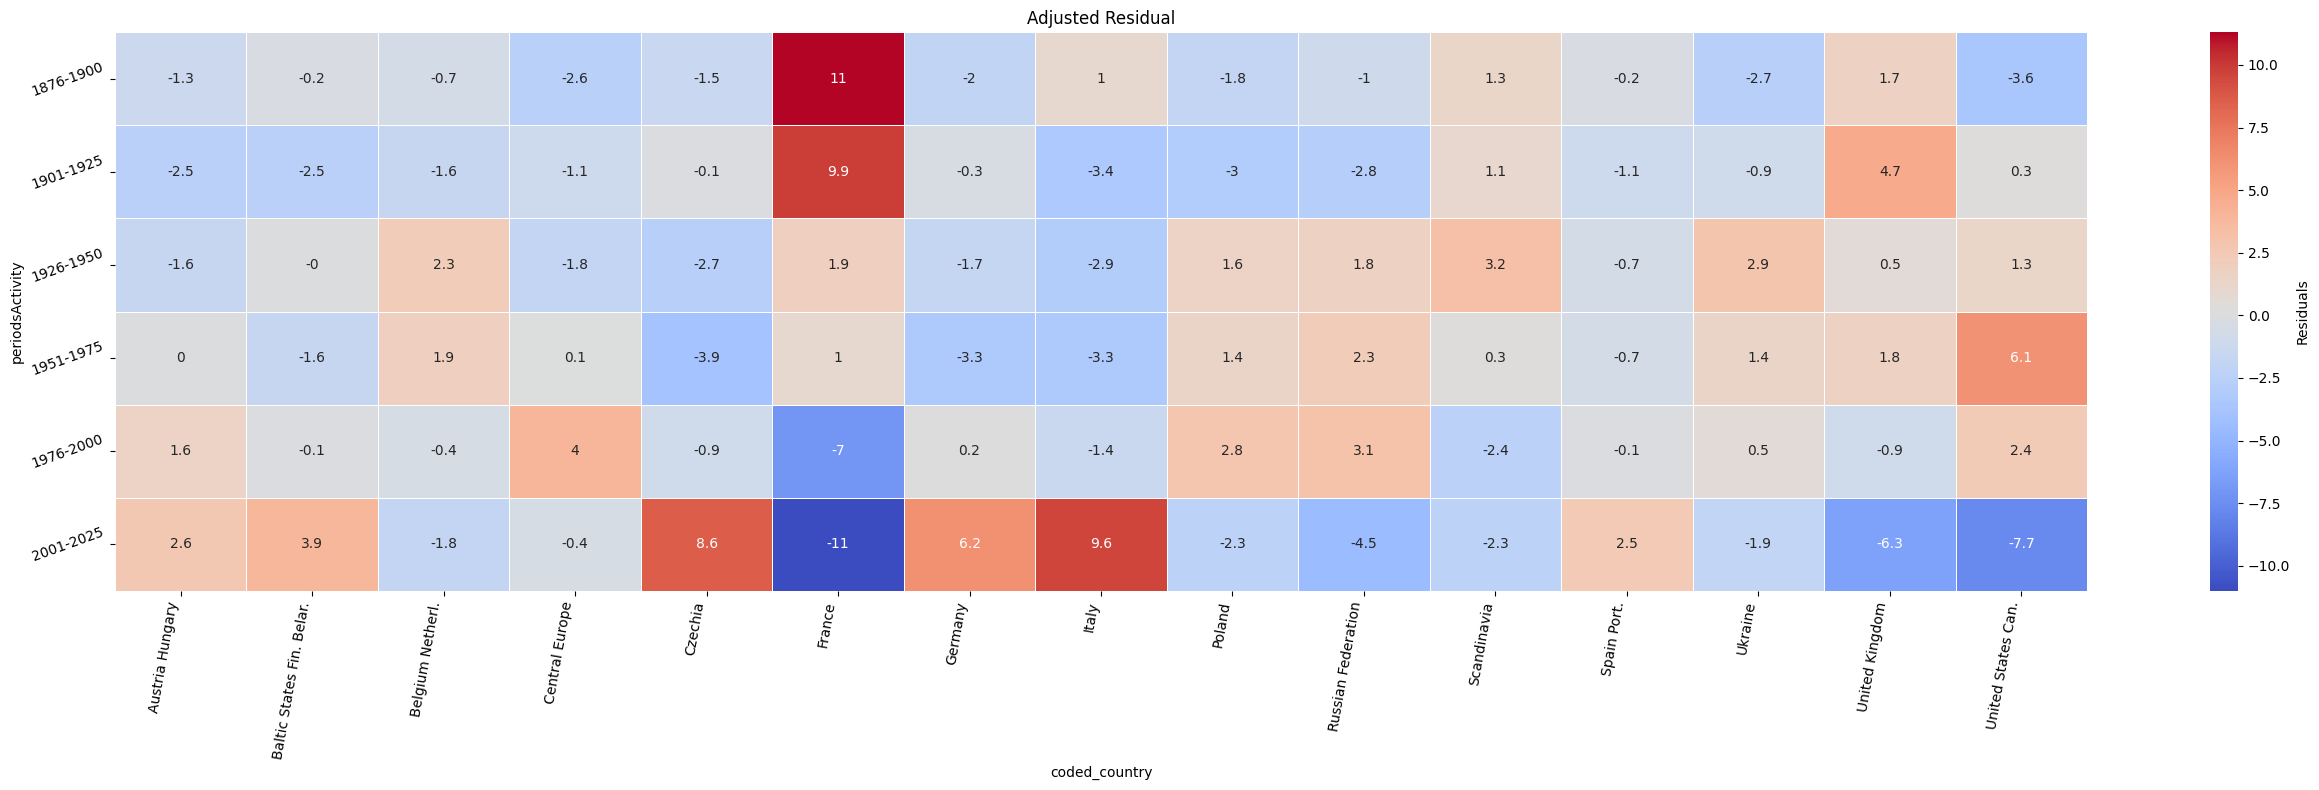

In [55]:
### Plot the residuals

# 3. Plot
fig, ax = plt.subplots(1,1,figsize=(26,8))         


# Create heatmap
sns.heatmap(
    adjusted_resids.round(1), 
    annot=True,            # Use boolean True to annotate with data values
    cmap="coolwarm", 
    linewidths=.5, 
    ax=ax,
    cbar_kws={'label': 'Residuals'}
)
# 3. Fix Label Rotation (Safe Method)
# This rotates existing ticks without risking a count mismatch
ax.set_xticklabels(ax.get_xticklabels(), rotation=80, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=20, va='center')
ax.set_title("Adjusted Residual", fontsize=12)

# ax.set_title("Heatmap of Adjusted Residuals (via statsmodels)")
plt.tight_layout()
plt.show()

In [56]:
## Compare with number
per_vs_country.iloc[2:]

coded_country,Austria Hungary,Baltic States Fin. Belar.,Belgium Netherl.,Central Europe,Czechia,France,Germany,Italy,Poland,Russian Federation,Scandinavia,Spain Port.,Ukraine,United Kingdom,United States Can.,All
periodsActivity,,,,,,,,,,,,,,,,
1876-1900,36,23,15,38,56,174,116,87,24,47,29,53,15,61,30,804
1901-1925,40,18,16,64,86,197,174,71,25,48,36,62,32,99,73,1041
1926-1950,55,36,38,70,77,143,187,91,61,96,53,77,61,80,94,1219
1951-1975,99,43,50,125,108,194,257,138,85,141,54,115,74,128,180,1791
1976-2000,154,74,53,218,199,166,432,228,129,201,56,170,94,147,198,2519
2001-2025,116,75,28,115,231,50,377,273,54,72,35,139,48,49,44,1706
All,531,292,224,656,786,1213,1629,999,410,651,297,638,339,639,632,9936


## Bivariate analysis genders

In [57]:
gender_vs_country=pd.crosstab(df_pa.gender, df_pa.coded_country, margins=True)
gender_vs_country

coded_country,Austria Hungary,Baltic States Fin. Belar.,Belgium Netherl.,Central Europe,Czechia,France,Germany,Italy,Poland,Russian Federation,Scandinavia,Spain Port.,Ukraine,United Kingdom,United States Can.,All
gender,,,,,,,,,,,,,,,,
female,105,51,33,131,153,93,252,248,66,100,62,147,49,120,154,1764
male,426,241,191,525,633,1120,1377,751,344,551,235,491,290,519,478,8172
All,531,292,224,656,786,1213,1629,999,410,651,297,638,339,639,632,9936


In [58]:
### Take the margins away
observed = gender_vs_country.iloc[:-1, :-1 ]
### Calcul des paramètres pour le test du Chi-2
statistic, p, dof, expected = stats.chi2_contingency(observed)
print('Chi2 :', statistic, ', dof :',dof)
print('p-value :', p)

Chi2 : 170.6707721407184 , dof : 14
p-value : 5.012037894814966e-29


In [59]:
### Cramér's phi coefficient
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html
vc = stats.contingency.association(observed, method='cramer')
print('Cramèr\'s V:', vc)

Cramèr's V: 0.13106109292453927


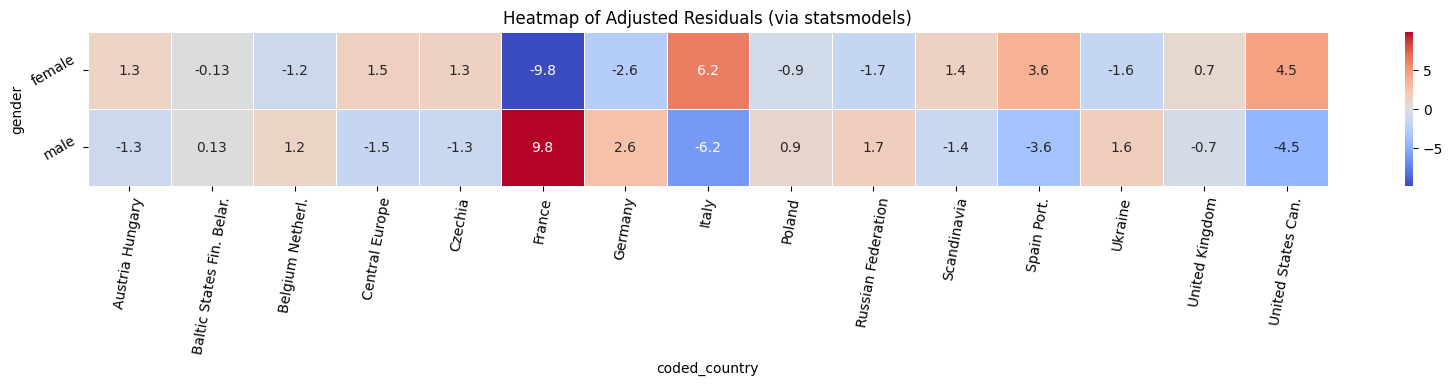

In [60]:
# 1. Create the Table object directly from your data
table = sm.stats.Table(observed)

# 2. Get Adjusted Residuals instantly (no manual formula needed)
adjusted_resids = table.standardized_resids
# 3. Plot
fig, ax = plt.subplots(figsize=(20,2))         
# Sample figsize in inches
ax = sns.heatmap(adjusted_resids, annot=adjusted_resids, cmap="coolwarm", linewidths=.5, ax=ax)
labels = adjusted_resids.index
p = ax.set_yticklabels(labels, rotation=30)
labels_cols = adjusted_resids.columns
p = ax.set_xticklabels(labels_cols, rotation=80)

ax.set_title("Heatmap of Adjusted Residuals (via statsmodels)")
plt.show()


We can observe that women are more present in some countries. The difference is statistically relevant although weak: Cramer's V = 0.131

## Bivariate analysis genders+generations vs countrys

In [61]:
def code_gender_period(gender: str):
    if gender == 'female':
        output='f'
    else:
        output='m'
    return output    

In [75]:
df_pa['per_gender']= df_pa.apply(lambda x: x.periodsActivity +'_'+ code_gender_period(x.gender), axis=1)
df_pa.head(2)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE,coded_country,activityYear,periodsActivity,per_gender
0,http://www.wikidata.org/entity/Q204508,NaN,1782,male,Sighișoara,POINT (24.791111 46.216945),http://www.wikidata.org/entity/Q193001,1781-1790,8,Eastern Europe,RO,România,Romania,ROU,Central Europe,1827,1826-1850,1826-1850_m
1,http://www.wikidata.org/entity/Q4525913,NaN,1790,male,Makhnivka,POINT (28.676944 49.721944),http://www.wikidata.org/entity/Q2511152,1781-1790,8,Eastern Europe,UA,Україна,Ukraine,UKR,Ukraine,1835,1826-1850,1826-1850_m


In [76]:
per_gender_vs_country=pd.crosstab(df_pa.per_gender, df_pa.coded_country, margins=True)
per_gender_vs_country.iloc[6:]

coded_country,Austria Hungary,Baltic States Fin. Belar.,Belgium Netherl.,Central Europe,Czechia,France,Germany,Italy,Poland,Russian Federation,Scandinavia,Spain Port.,Ukraine,United Kingdom,United States Can.,All
per_gender,,,,,,,,,,,,,,,,
1901-1925_f,2,0,1,0,0,4,3,0,1,3,0,0,1,16,15,46
1901-1925_m,38,18,15,64,86,193,171,71,24,45,36,62,31,83,58,995
1926-1950_f,2,3,6,4,10,12,19,11,10,13,3,3,6,20,22,144
1926-1950_m,53,33,32,66,67,131,168,80,51,83,50,74,55,60,72,1075
1951-1975_f,23,10,4,25,18,20,28,20,16,34,14,24,21,39,50,346
1951-1975_m,76,33,46,100,90,174,229,118,69,107,40,91,53,89,130,1445
1976-2000_f,40,14,15,61,53,38,81,73,29,41,22,70,14,28,55,634
1976-2000_m,114,60,38,157,146,128,351,155,100,160,34,100,80,119,143,1885
2001-2025_f,38,23,7,40,72,16,118,143,10,9,22,50,6,10,10,574


In [77]:
### Only mor recent periods
observed = per_gender_vs_country.iloc[6:-1, :-1 ]

In [78]:
### For significant chi-2 test minimal number in each cell of expected:5
# bias in the results
statistic, p, dof, expected = stats.chi2_contingency(observed)
dfe = pd.DataFrame(expected).round(0)
dfe.index = observed.index
dfe.columns = observed.columns
dfe

coded_country,Austria Hungary,Baltic States Fin. Belar.,Belgium Netherl.,Central Europe,Czechia,France,Germany,Italy,Poland,Russian Federation,Scandinavia,Spain Port.,Ukraine,United Kingdom,United States Can.
per_gender,,,,,,,,,,,,,,,
1901-1925_f,3.0,1.0,1.0,3.0,4.0,4.0,8.0,4.0,2.0,3.0,1.0,3.0,2.0,3.0,3.0
1901-1925_m,56.0,30.0,22.0,71.0,84.0,90.0,172.0,96.0,43.0,67.0,28.0,68.0,37.0,60.0,71.0
1926-1950_f,8.0,4.0,3.0,10.0,12.0,13.0,25.0,14.0,6.0,10.0,4.0,10.0,5.0,9.0,10.0
1926-1950_m,60.0,32.0,24.0,77.0,91.0,97.0,185.0,104.0,46.0,72.0,30.0,73.0,40.0,65.0,77.0
1951-1975_f,19.0,10.0,8.0,25.0,29.0,31.0,60.0,33.0,15.0,23.0,10.0,24.0,13.0,21.0,25.0
1951-1975_m,81.0,43.0,32.0,103.0,122.0,131.0,249.0,140.0,62.0,97.0,41.0,98.0,54.0,88.0,103.0
1976-2000_f,36.0,19.0,14.0,45.0,54.0,57.0,109.0,61.0,27.0,43.0,18.0,43.0,24.0,39.0,45.0
1976-2000_m,106.0,56.0,42.0,135.0,160.0,171.0,325.0,182.0,81.0,127.0,53.0,128.0,70.0,115.0,134.0
2001-2025_f,32.0,17.0,13.0,41.0,49.0,52.0,99.0,56.0,25.0,39.0,16.0,39.0,21.0,35.0,41.0


In [79]:
print('Chi2 :', statistic, ', dof :',dof)
print('p-value :', p)

Chi2 : 1082.5961185147466 , dof : 126
p-value : 8.812897496669898e-152


In [80]:
### Cramér's phi coefficient
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html
vc = stats.contingency.association(observed, method='cramer')
print('Cramèr\'s V:', vc)

Cramèr's V: 0.1205595829924899


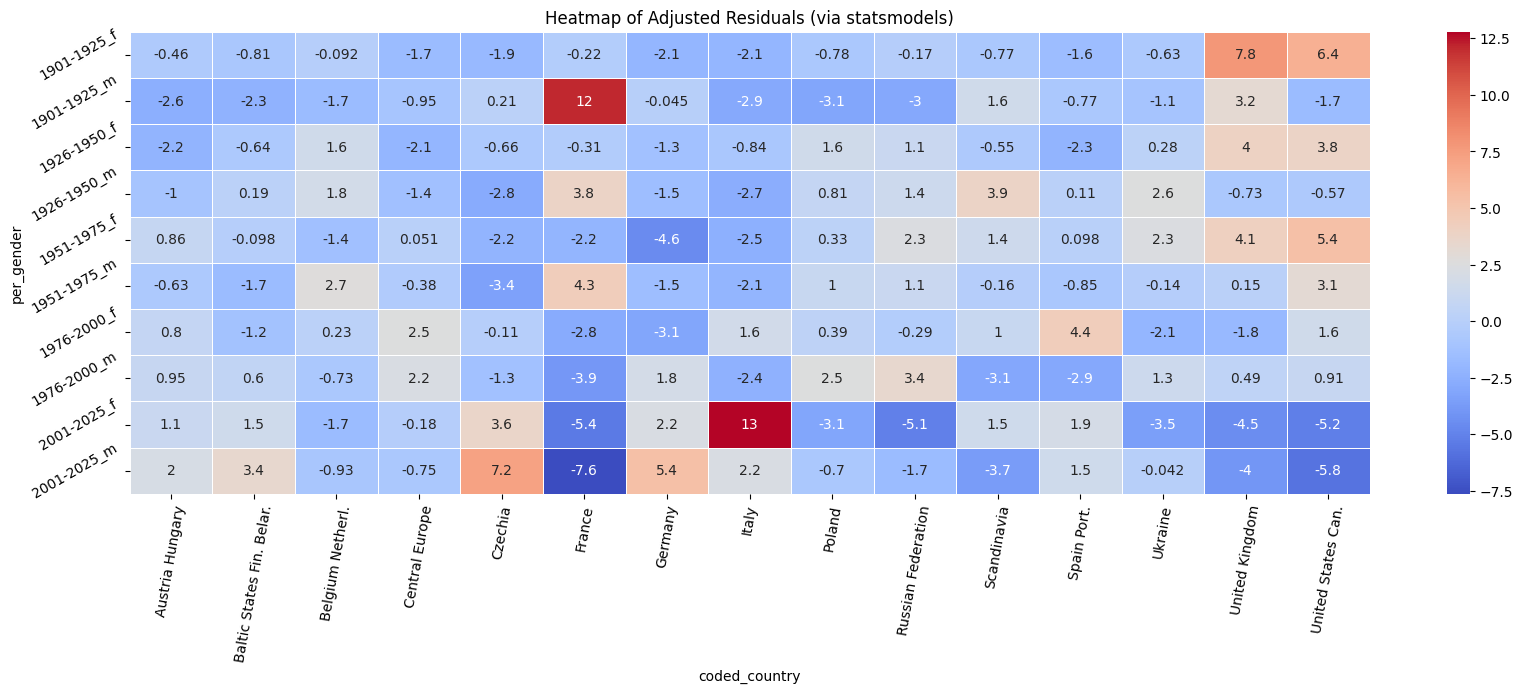

In [81]:
# 1. Create the Table object directly from your data
table = sm.stats.Table(observed)

# 2. Get Adjusted Residuals instantly (no manual formula needed)
adjusted_resids = table.standardized_resids
# 3. Plot
fig, ax = plt.subplots(figsize=(20,6))         
# Sample figsize in inches
ax = sns.heatmap(adjusted_resids, annot=adjusted_resids, cmap="coolwarm", linewidths=.5, ax=ax)
labels = adjusted_resids.index
p = ax.set_yticklabels(labels, rotation=30)
labels_cols = adjusted_resids.columns
p = ax.set_xticklabels(labels_cols, rotation=80)

ax.set_title("Heatmap of Adjusted Residuals (via statsmodels)")
plt.show()


In [82]:
dfs = df_pa[(df_pa.per_gender.isin(['1901-1925_f']))&(df_pa.coded_country.isin(['United States Can.', 'United Kingdom']))]
print(len(dfs))

31


In [83]:
dfs.head(10)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE,coded_country,activityYear,periodsActivity,per_gender
1600,http://www.wikidata.org/entity/Q1906390,NaN,1857,female,Norfolk,POINT (0.95 52.6725),http://www.wikidata.org/entity/Q23109,1851-1860,24,Northern Europe,UK,United Kingdom,United Kingdom,GBR,United Kingdom,1902,1901-1925,1901-1925_f
1606,http://www.wikidata.org/entity/Q187410,NaN,1857,female,San Francisco,POINT (-122.419445 37.775),http://www.wikidata.org/entity/Q62,1851-1860,23,Northern America,US,United States,United States,USA,United States Can.,1902,1901-1925,1901-1925_f
1850,http://www.wikidata.org/entity/Q519129,NaN,1860,female,London,POINT (-0.1275 51.507222),http://www.wikidata.org/entity/Q84,1851-1860,24,Northern Europe,UK,United Kingdom,United Kingdom,GBR,United Kingdom,1905,1901-1925,1901-1925_f
2086,http://www.wikidata.org/entity/Q4212534,NaN,1869,female,Neath,POINT (-3.81 51.66),http://www.wikidata.org/entity/Q2003342,1861-1870,24,Northern Europe,UK,United Kingdom,United Kingdom,GBR,United Kingdom,1914,1901-1925,1901-1925_f
2108,http://www.wikidata.org/entity/Q1370020,NaN,1862,female,South Salem,POINT (-83.3075 39.3364),http://www.wikidata.org/entity/Q2668520,1861-1870,23,Northern America,US,United States,United States,USA,United States Can.,1907,1901-1925,1901-1925_f
2156,http://www.wikidata.org/entity/Q6376534,NaN,1866,female,Darlington,POINT (-1.557222 54.522778),http://www.wikidata.org/entity/Q213181,1861-1870,24,Northern Europe,UK,United Kingdom,United Kingdom,GBR,United Kingdom,1911,1901-1925,1901-1925_f
2166,http://www.wikidata.org/entity/Q6543589,NaN,1868,female,Boston,POINT (-71.057778 42.360278),http://www.wikidata.org/entity/Q100,1861-1870,23,Northern America,US,United States,United States,USA,United States Can.,1913,1901-1925,1901-1925_f
2170,http://www.wikidata.org/entity/Q17364601,NaN,1861,female,Cambridge,POINT (-71.106111 42.375),http://www.wikidata.org/entity/Q49111,1861-1870,23,Northern America,US,United States,United States,USA,United States Can.,1906,1901-1925,1901-1925_f
2177,http://www.wikidata.org/entity/Q231360,NaN,1868,female,Washington,POINT (-1.52 54.9),http://www.wikidata.org/entity/Q1018448,1861-1870,24,Northern Europe,UK,United Kingdom,United Kingdom,GBR,United Kingdom,1913,1901-1925,1901-1925_f
2198,http://www.wikidata.org/entity/Q6153361,NaN,1863,female,Dundee,POINT (-2.97 56.460556),http://www.wikidata.org/entity/Q123709,1861-1870,24,Northern Europe,UK,United Kingdom,United Kingdom,GBR,United Kingdom,1908,1901-1925,1901-1925_f


### Inspected persons

* [Mary Rothes Margaret Cecil, Baroness Amherst of Hackney](https://www.wikidata.org/wiki/Q1906390) (UK)
* [Zelia Nuttall](http://www.wikidata.org/entity/Q187410) (US)